In [1]:
from src.data_loader import load_logreturns, load_prices
from src.features import create_features
from src.models import train_linear_regression, model_prediction, evaluate_performance, compare_prediction,train_random_forest, train_neural_network, train_reduced_neural_network, validate_seed_robustness,find_feature_importance, choose_architecture, tune_random_forest, train_and_predict_garch, feature_ablationtest_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from scipy.stats import norm
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
random.seed(42)
np.random.seed(42)


# Asset Return Model Comparison: Geometric Brownian Motion vs. Machine Learning
### Summary
- **Data**: S&P-500 daily returns, 2020 - 2026, sourced via yfinance
- **Part 1**: Empirical analysis of return distributions and volatility structure: we reproduce several of the stylized facts documented in Cont(2001) for our data set
- **Part 2**: GBM calibrated to historical parameters; systematic comparison reveals failure to reproduce heavy tails and volatility clustering
- **Part 3**: Machine learning approaches to capture the higher-order statistical structure that GBM fails to reproduce.

## Introduction

Geometric Brownian Motion (GBM) assumes returns are normally distributed and independent. Neither holds empirically. This project quantifies how large that gap is and tests whether machine learning can close it.

Our goal for this project is to compare the statistical features of S&P 500 returns to those of GBM and identify the aspects GBM fails to model. We then examine whether a deep learning model can capture some of these statistical features in its place. 

Our motivation for using GBM as our comparison model comes from the Black Scholes options pricing model which uses the GBM as a base and is the basis for the most commonly used options pricing frameworks. 

In this first part we reproduce some of the famous stylized empirical facts from the influential paper, *Empirical properties of asset returns: stylized facts and statistical issues* (Rama Cont, 2001), which highlighted the statistical differences between Gaussian models and empirical asset returns. 

In the second part we calibrate a GBM to the historical data and compare it directly to the empirical results. 

In the third part we use three different machine learning approaches to capture the conditional volatility structure and nonlinear dependencies absent in classical GBM dynamics. 

## Part 1: Empirical Properties of S&P-500 Returns
### Distributional Statistics

We begin by examining the distributional properties of S&P-500 log returns. The GBM model assumes returns are normally distributed. We test this assumption by analyzing the empirical distribution, looking specifically for heavy tails and excess kurtosis, both of which Cont (2001) identifies as universal properties of asset returns.

We first load the log returns of our data, in this case the S&P-500 price data starting in 2020 and create a basic plot.



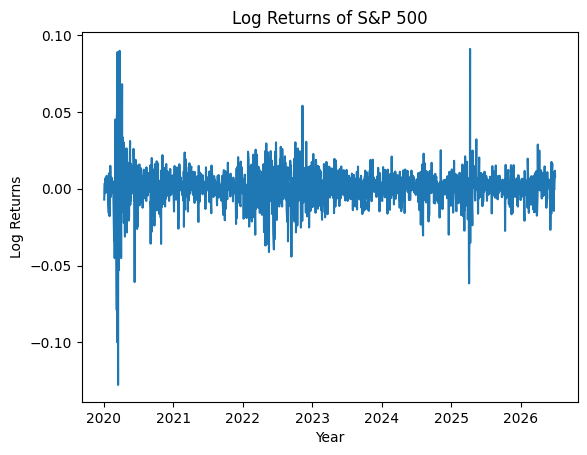

In [2]:
returns = load_logreturns()
prices =  load_prices()

plt.plot(returns)
plt.title("Log Returns of S&P 500")
plt.xlabel("Year")
plt.ylabel("Log Returns")
plt.show()


From visual inspection, volatility clustering appears apparent in the 2020 spike with increased volatility afterwards as well as lower magnitude clustering of large moves at different periods throughout the data.  We will quantify this below in the section "Temporal Characteristics."

To examine the assumption of Gaussian distributed increments we calculate the mean, std, and excess kurtosis so that we can compare the distribution of our data directly with a Gaussian distribution of the same mean and variance.

In [3]:
mean = np.mean(returns)
std = np.std(returns)
excess_kurtosis = kurtosis(returns)
# Since sci-kit calculates excess kurtosis (kurtosis - 3) by default, 
# for better readability we calculate kurtosis
kurtosis_ = excess_kurtosis + 3

print('The mean is:', mean)
print('The standard deviation is:', std)
print('The kurtosis is:', kurtosis_)

The mean is: 0.0005115031697896541
The standard deviation is: 0.012942011957225373
The kurtosis is: 17.79793966619308


We see that the mean is close to 0 relative to the standard deviation. Short term price movements are dominated by noise. 

The standard deviation is large relative to the mean, indicating substantial randomness and uncertainty in daily returns.

Though these two properties could be consistent with GBM the final property shows the first statistical property of our empirical asset data that violate the assumptions underlying GBM:

The S&P 500 time series data shows pronounced evidence of fat tails with kurtosis >> 3. Since Gaussian distributions have excess kurtosis of 3, this means that extreme events happen more often than Gaussian models (like GBM) predict. 

We have already reproduced one of the stylized facts (fat tails) and identified a statistical property our GBM model will fail to replicate. 

To compare our empirical data more directly with a Gaussian distribution we create a plot overlaying our data with a Gaussian distribution of the same mean and variance. 

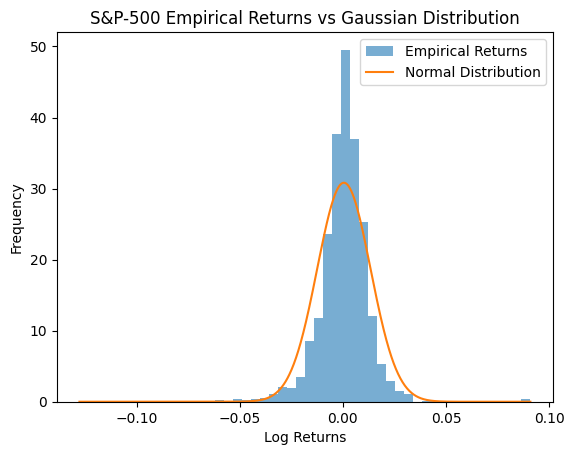

In [4]:
x = np.linspace(returns.min(), returns.max(), 1000)
gauss_y_val = norm.pdf(x, mean, std)

plt.hist(returns,bins=50,density=True, alpha=0.6,label='Empirical Returns')
plt.plot(x, gauss_y_val, label="Normal Distribution")
plt.title("S&P-500 Empirical Returns vs Gaussian Distribution")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("../images/Fat-tailed_S&P500Distribution")
plt.show()

As expected by the kurtosis of the data, we observe sharper peaks and fatter tails compared to the Gaussian benchmark.

The Gaussian model fails to capture the two extremes accurately. It understimates the likelyhood of both tiny movements and huge movements compared to the real observations in the empirical data. On the other hand, the Gaussian model overestimates the likelyhood of mid-sized movements.

Translating this empirical observation into the intuition of financial markets, our empirical data tells us that the market tends to spend a lot of time being relatively quiet while occasionally making huge moves. It alternates between calm regimes and turbulent regimes. This relates directly to the idea of volatility clustering. The Gaussian model assumes constant volatility.

### Temporal Structure

We will examine our data more closely looking for evidence of volatility clustering. To do this we plot the standard deviation over a rolling window of 20 days. This will give us a time series to examine the change of the volatility over time.

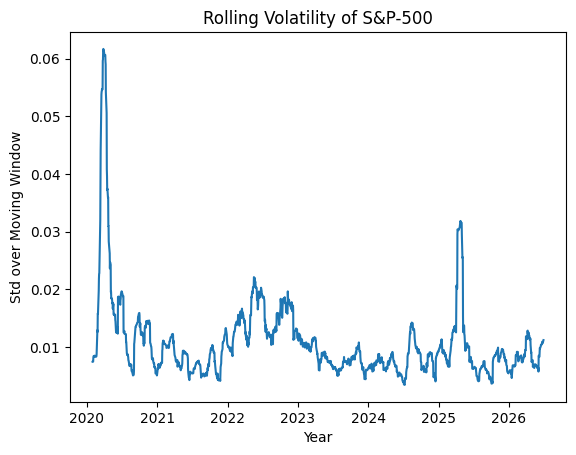

In [5]:
volatility = returns.rolling(20).std()
plt.plot(volatility)
plt.title("Rolling Volatility of S&P-500")
plt.xlabel("Year")
plt.ylabel("Std over Moving Window")
plt.show()


From the plot we can see that the volatility varies significantly over time. 

Periods of higher volatility tend to cluster together, suggesting that variance is time-dependent rather than constant. 

A Gaussian model assumes constant volatility, thus will not be able to capture this statistical property. 

### Autocorrelation

We now wish to examine the predictability of the returns as well as for volatility. For this we examine the autocorrelation of the returns and of the squared returns. Since volatility is related to magnitude, not direction, the squared returns serve as a rough approximation for the volatility:

In [6]:
autocorrelation_returns = returns.autocorr()
autocorrelation_squaredreturns = (returns**2).autocorr()
print('Autocorrelation of returns:', autocorrelation_returns)
print('Autocorrelation of squared returns:', autocorrelation_squaredreturns)

Autocorrelation of returns: -0.16523629851945384
Autocorrelation of squared returns: 0.45446495369709794


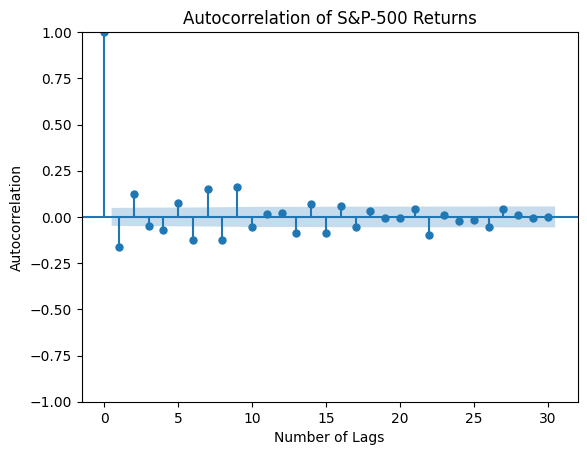

In [7]:
plot_acf(returns, lags=30)
plt.title("Autocorrelation of S&P-500 Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

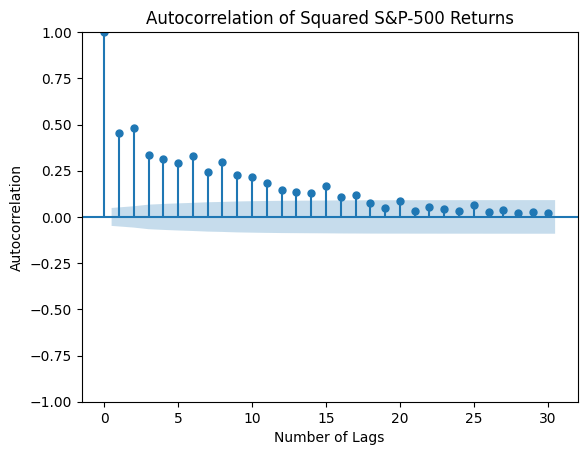

In [8]:
plot_acf(returns**2,lags=30)
plt.title("Autocorrelation of Squared S&P-500 Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

Comparing the two plots, we notice the ACF plot of the returns appears very noisy with no clear decay pattern. Despite having isolated statistically siginficant autocorrelation values outside of the confidence window, the values are still small and are likely a result of noise. This suggests limited linear predictability in returns themselves. 

On the other hand, the squared returns show consistent statistically significant autocorellation up to about 15 lags with slow linear decay with respect to the number of lags. This behavior is consistent with volatility clustering. 

Taking all these statistical facts together (kurtosis, heavy tails, volatility clustering) the higher order statistics of the S&P-500 demonstrate clearly non-Gaussian behavior. 

We will put these statistical observations to the test directly by building a GBM model and comparing the behavior directly.

## GBM Model
### Distributional Statistics

We import the GBM model. We first compare the prices and log returns simulated by a single GBM path.

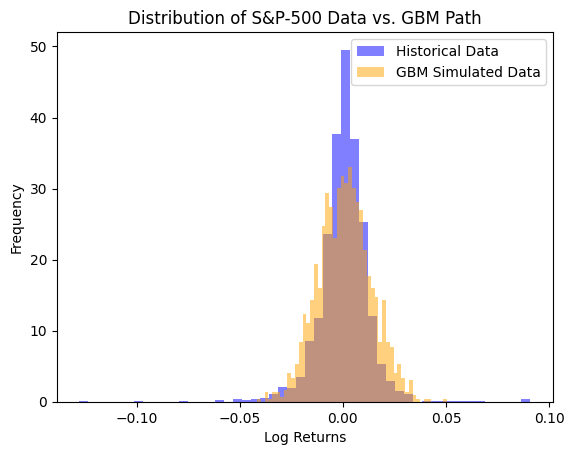

In [9]:
from src.gbm import simulate_GBM
simulated_prices = simulate_GBM(prices, returns)
simulated_logreturns = np.diff(np.log(simulated_prices))
plt.hist(returns, bins=50,alpha=0.5,density=True, color='blue', label="Historical Data")
plt.hist(simulated_logreturns, bins=50, alpha=0.5, density=True, color='orange',label="GBM Simulated Data")
plt.title("Distribution of S&P-500 Data vs. GBM Path")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()


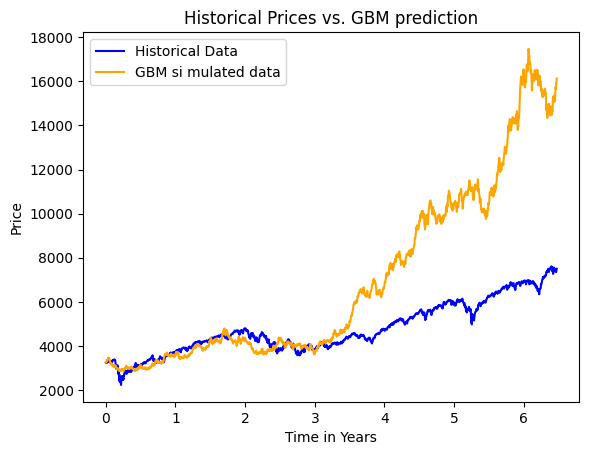

In [10]:
t = np.linspace(0, len(prices)/252, len(prices))
plt.plot(t, prices.values, color='blue', label='Historical Data')
plt.plot(t, simulated_prices, color='orange', label='GBM si mulated data')
plt.title('Historical Prices vs. GBM prediction')
plt.xlabel('Time in Years')
plt.ylabel('Price')
plt.legend()
plt.show()

We notice that the GBM very roughly models the S&P-500, generally following the same trend. The histogram comparison shows, similarily to the Gaussian overlay, that the true S&P-500 data has sharper peaks, heavier tails and less "mid-sized" movements compared to the GBM. 

We now increase the number of simulations in a Monte-Carlo type simulation and determine the average path of our GBM, plotting each simulation in comparison to the true S&P-500 data. 

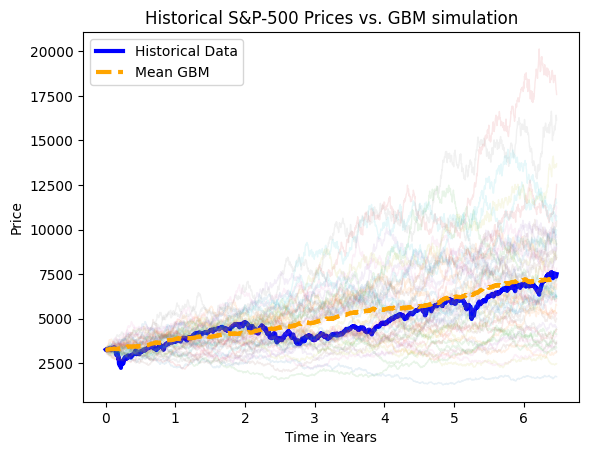

In [11]:
#number or simulations
n = 50
plt.plot(t, prices.values, color='blue',linewidth=3, label='Historical Data')
average_simprices = np.zeros((len(prices)))
all_sim_returns = []
for i in range(n):
    prices_estimate = simulate_GBM(prices, returns)
    average_simprices = (average_simprices + prices_estimate)
    sim_log_returns = np.diff(np.log(prices_estimate))
    all_sim_returns.extend(sim_log_returns)
    plt.plot(t, prices_estimate, alpha=0.1, linewidth=1)
average_simprices = average_simprices * 1/n 
plt.plot(t, average_simprices,color='orange', linewidth=3, linestyle='--', label='Mean GBM')  
plt.title("Historical S&P-500 Prices vs. GBM simulation")
plt.xlabel('Time in Years')
plt.ylabel('Price')
plt.legend()
plt.savefig("../images/GBMpathsvsSP500paths.png",dpi=300,bbox_inches="tight")
plt.show()

We now compare the histograms of the log returns of the historical data vs the simulated GBM paths. 

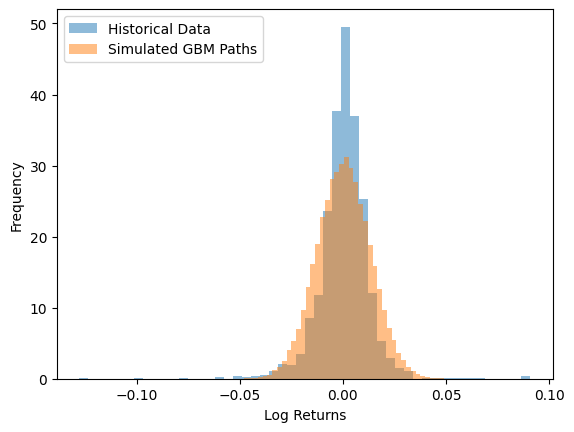

In [12]:
plt.hist(returns, bins=50, density=True, alpha=0.5,label="Historical Data")
plt.hist(all_sim_returns, bins=50,density=True,alpha=0.5,label='Simulated GBM Paths')
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Here we see that by increasing the number of GBM paths we approach a Gaussian distribution more closely. As predicted by our analysis of the historical data, the GBM model generally underestimates extreme daily movements (very small amplitude, or very large amplitude) and overestimates mid-sized movements. 

We now evaluate the kurtosis of our simulated returns.

In [13]:
all_simulated_excess_kurtosis = kurtosis(all_sim_returns)
# We convert the excess kurtosis calculated by default by scikit to kurtosis for better readability
all_simulated_kurtosis = all_simulated_excess_kurtosis + 3
simulated_excess_kurtosis = kurtosis(simulated_logreturns)
simulated_kurtosis = simulated_excess_kurtosis + 3
print('The kurtosis of the log returns of a single simulated GBM path is:', simulated_kurtosis)
print('The kurtosis of the log returs of many simulated GBM paths is:', all_simulated_kurtosis)

The kurtosis of the log returns of a single simulated GBM path is: 3.0247881186159735
The kurtosis of the log returs of many simulated GBM paths is: 2.9889268598274565


As expected the kurtosis of the simulated GBM paths is very close to 3
 only showing negligible evidence of heavy tails.

Now that we have compared the distributional statistics of the data vs. the GBM model we examine the temporal structure. 

### Temporal Structure

We compare the rolling volatility over a moving window of 20 days of our simulated GBM path to that of the S&P-500 data.

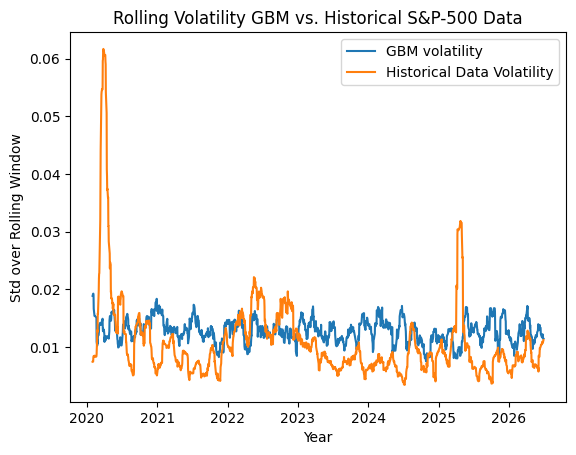

In [14]:
sim_log_returns = pd.Series(sim_log_returns, index=returns.index)
volatility_gbm = sim_log_returns.rolling(20).std()
plt.plot(volatility_gbm, label="GBM volatility")
plt.plot(volatility, label="Historical Data Volatility")
plt.title("Rolling Volatility GBM vs. Historical S&P-500 Data")
plt.xlabel("Year")
plt.ylabel("Std over Rolling Window")
plt.legend()
plt.savefig("../images/rolling_volatility_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

Compared to the volatility of the historical data, the volatility of the simulated GBM path is relatively constant with only small fluctuations. The volatility of the historical data is roughly centered around the volatility of the GBM but exhibits much larger deviations. 

Since the GBM model is calibrated with the empirical standard deviation, the GBM model can capture the overall fluctuation magnitude but assumes constant volatility, which is not true for the historical data.

As we did for the historical data, we calculate the autocorrelation of the returns and of the squared returns. 

In [15]:
autocorrelation_gbmreturns = sim_log_returns.autocorr()
autocorrelation_squaredgbmreturns = (sim_log_returns**2).autocorr()
print('Autocorrelation of returns:', autocorrelation_gbmreturns)
print('Autocorrelation of squared returns:', autocorrelation_squaredgbmreturns)

Autocorrelation of returns: -0.02441902779477701
Autocorrelation of squared returns: 0.0015150032404286033


Neither returns nor squared returns show significant autocorrelation. In contrast to the historical data, we see no signs of volatility clustering. GBM assumes constant volatility.  

We plot the ACF plots of returns and squared returns to examine this more deeply.

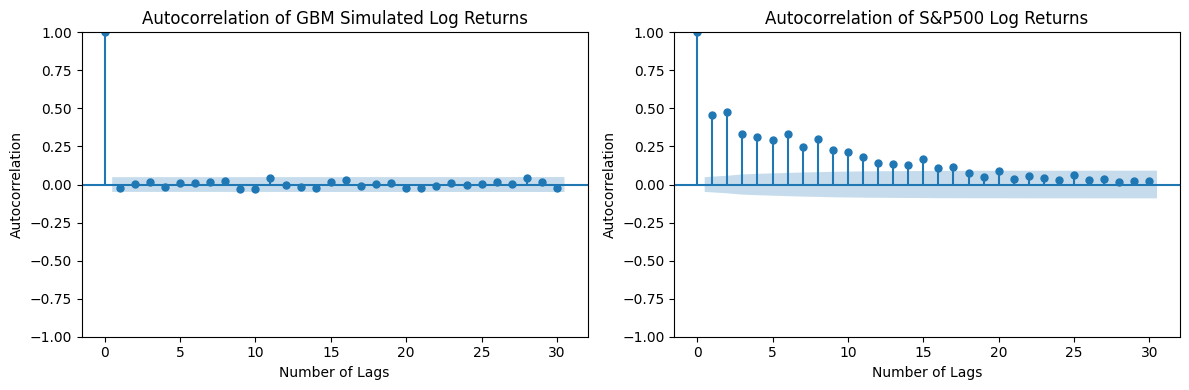

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(sim_log_returns, lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation of GBM Simulated Log Returns")
axes[0].set_xlabel("Number of Lags")
axes[0].set_ylabel("Autocorrelation")
plot_acf(returns**2, lags=30, ax=axes[1])
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
axes[1].set_title("Autocorrelation of S&P500 Log Returns")
axes[1].set_xlabel("Number of Lags")
axes[1].set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("../images/SP500vsGBMReturnsAutocorrelation.png",dpi=300,bbox_inches="tight")
plt.show()

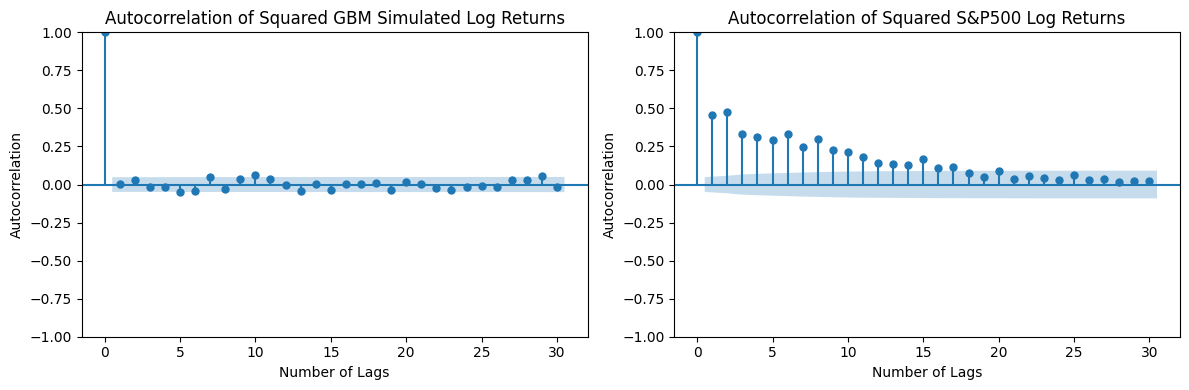

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(sim_log_returns**2, lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation of Squared GBM Simulated Log Returns")
axes[0].set_xlabel("Number of Lags")
axes[0].set_ylabel("Autocorrelation")
plot_acf(returns**2, lags=30, ax=axes[1])
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
axes[1].set_title("Autocorrelation of Squared S&P500 Log Returns")
axes[1].set_xlabel("Number of Lags")
axes[1].set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("../images/SP500vsGBMSquaredReturnsAutocorrelation.png",dpi=300,bbox_inches="tight")
plt.show()

The ACF plots of the GBM model show that neither returns nor squared returns show significant autocorellation across lags, consistent with the assumption of independent Gaussian increments with only isolated spikes, randomly fluctuating near zero. 

This contrasts sharply with the historical data, where the squared returns showed significant autocorellation with a clear decay pattern. The GBM model fails to model the persistent volatility dynamics present in the historical data. 

### Final Analysis GBM Model vs. Historical S&P-500 Data
Our GBM Model calibrated to the historical data is able to reproduce some first order properties:
 
 - Both the empirical returns and simulated returns lack strong long-range autocorrelation structure. Still, the empirical data exhibits noticeably larger short-lag fluctuations than the GBM simulations, suggesting deviations from the iid increment assumption. 
 
 - The GBM paths reproduced a similar scale of fluctuations. The resulting paths exhibited qualitatively plausible stochastic price behavior. 

However, the GBM model failed to reproduce some higher order statistical properties: 
- The model showed kurtosis close to 3, while the historical data had kurtosis >> 3, showing pronounced heavy-tail structure. The Gaussian increment assumption significantly underestimates the frequency of extreme market movements.
- While the rolling volatility analysis of the historical data showed persistant periods of elevated and reduced volatility, the GBM simulations showed a much flatter rolling volatility curve with structureless fluctuations reflecting the models assumption of constant variance. 
- The empirical squared returns exhibited persistent positive autocorrelation with a marked decay structure, indicating volatility clustering and time-varying variance. The GBM model showed squared-return autocorrelations fluctuating near zero, consistent with independent increments and constant volatility.

The analysis suggests that financial time series cannot fully be characterized by low-order statistics such as mean and variance. Temporal dependence in volatility-related quantities constitutes an important aspect of market dynamics absent from the classical GBM framework.

The observed differences in the simulated data vs. the historical S&P-500 data are caused directly by the assumptions of the GBM, particularly the assumptions of iid Gaussian increments and constant volatility. While these assumptions yield a mathematically elegant stochastic framework, they do not adequately reproduce the higher-order structure observed in empirical market data. 

Despite these limitations, the GBM remains an important baseline model due to its analytical simplicity and its central role in classical quantitative finance i.e. the derivation of the Black-Scholes framework. 

The observed persistence in volatility-related quantities naturally motivates more sophisticated stochastic models that incorporate time-varying or stochastic volatility such as GARCH.

This motivates us to the second part of this project, where we see if we can capture some of these higher order statistical properties through machine learning.

## Machine Learning Models to capture Higher-Order Structure

The analysis of the S&P-500 historical data compared with the GBM simulations indicates, that although return directions are difficult to predict, volatility-related quantities exhibit persistent temporal dependence absent from the GBM framework. This distinction motivates the transition from classical diffusion-based modeling towards machine learning approaches focused on predicting conditional volatility dynamics. 

We will implement three machine learning models of increasing complexity: linear regression model, Random Forrest algorithm, and a feed forward neural network. As our target we choose 5-day realized volatility shifted 5 trading days ahead. 

We begin with the linear regression model. 

### Training and Test Data

In [18]:
# Data preparation

# We split our features data frame into data X and target Y. 
# As our target we choose the future realized volatility (calculated as std over rolling window of 5 days) 5 trading days into the future

features = create_features(returns)
X = features.drop(columns=["target"])
y = features["target"] 

# Since we are working with time series data, the data has to be split chronologically, 
# not randomly to avoid look ahead bias and keep the temporal structure relevant to our features intact.
# For simplicity and readability for this notebook we choose a single split.
# For more rigorous validation in other contexts I would consider for instance walk forward split 

splitting_index = int(len(features)* 0.8)
X_trainandvalidation = X[:splitting_index]
Y_trainandvalidation = y[:splitting_index]
train_index = int(len(X_trainandvalidation)*0.8)
X_train = X_trainandvalidation[:train_index]
Y_train = Y_trainandvalidation[:train_index]
X_validation = X_trainandvalidation[train_index:]
Y_validation = Y_trainandvalidation[train_index:]
X_test = X[splitting_index:]
Y_test = y[splitting_index:]


### Feature Baseline
We first train our models on a collection of features we choose motivated by our previous analysis. After training the models we will re-examine the selection of features based on their correlation. We choose each feature to capture a different characteristic of our time series data that could be useful for predicting volatility: 
- **Log Returns** to capture pointwise directional shocks
- **Realized volatility** calculated over rolling window (i.e  returns.rolling(vol_window).std): this captures local volatility structure, medium-term volatility state
- **Lagged realized volatility** with lags 1, 5, 10 to capture volatility persistence in short, medium and long term
- **Absolute returns** to capture shock magnitude
- **Squared returns** as a pointwise volatility proxy
- **Rolling mean** to capture local directional regime
- **Rolling kurtosis** to capture information about changes in likelyhood  of extreme movements

### Linear Regression model and GARCH (1,1) Benchmark
Since our data showed signs of volatility persistence with strong linear autocorrelation in squared returns, a basic linear model should show some sucess. We compare our linear model vs. two baseline models: a Geralized Autoregressive Conditional Heroskedasticity (GARCH) (1,1) model as well as a naive prediction, relying only on volatility persistence, predicting the current realized volatility as the future volatility at every moment. 

We choose the GARCH (1,1) model as our more competitive baseline model as it is the standard base model for volatility forecasting in financial time series. 

Our target variable for the volatility forecasting problem is a 5-day-ahead realized volatility calculated on a rolling window of 5 days. Expressing this mathematically, for each time point $t$ this is the sample standard deviation of the log returns $r_{t + 1}, r_{t+2}, ..., r_{t + 5},$ i.e $$RV_t = \sqrt{\frac{1}{4} \sum_{i=1}^{5} (r_{i} - \overline{r})},$$where $\overline{r}$ is the mean of the returns $r_{t+1},...,r_{t+5}.$ Since the GARCH model predicts conditional variance for fixed time points, to obtain a roughly comparable target, for each time point t we define the GARCH (1,1) model's prediction of volatility to be the square root of the average of the predicted conditional variances $\hat{\sigma}_{t+1}, \hat{\sigma}_{t+2}, ...,\hat{\sigma}_{t+5},$ i.e: $$GARCHpred_{t} = \sqrt{\frac{1}{5}\sum_{i=1}^{5}{\hat{\sigma}_{i}}}.$$
Thus, $RV_{t}$ is a sample standard deviation computed from realized returns which inherits the properties of a sampled statistic i.e sample mean, as well as the use of Bessel's correction (denominator n-1 instead of n) whereas $GARCHpred_{t}$ is derived from conditional variance predictions representing a theoretical estimate of average daily volatility in the window instead of empirical volatility. Despite this fundamental difference, they both offer estimates of the same quantity: the magnitude of average daily return fluctuations in the 5-day-lookahead window. The practical numerical differences introduced by their respective differences (sample mean vs GARCH assumed mean=0) and sample vs population std are expected to be small since daily return means are typically negligible compared to their standard deviations. 

We train our linear model on the training set. We hold out a validation set for feature selection, but already compare baseline performance. 

In [19]:
linear_model, scaler = train_linear_regression(X_train, Y_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns, index=X_train.index)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns, index=X_test.index)
X_validation_scaled = scaler.transform(X_validation)
X_validation_scaled = pd.DataFrame(X_validation_scaled, columns=X_validation.columns, index=X_validation.index)
pred_test = model_prediction(linear_model, X_test_scaled)
pred_test = pd.Series(pred_test, index=Y_test.index)
naive_pred_train = X_train["realized_vol"]
naive_pred_test = X_test["realized_vol"]

garch_pred = train_and_predict_garch(returns, Y_test)
common_index = (Y_test.index.intersection(pred_test.index).intersection(garch_pred.index).intersection(naive_pred_test.index))
y_common = Y_test.loc[common_index]
linear_common = pred_test.loc[common_index]
garch_common = garch_pred.loc[common_index]
naive_common = naive_pred_test.loc[common_index]
compare_prediction("Test Prediction Results Garch (1,1) Model vs. Naive Model",naive_common, "Naive Prediction", garch_common, "Garch (1,1) Model", y_common)
compare_prediction("Test Prediction Results Linear Model vs. Naive Model", naive_common, "Naive Prediction", linear_common, "Linear Model", y_common)
compare_prediction("Test prediction Results Linear Model vs GARCH (1,1)", garch_common, "GARCH (1,1)", linear_common, "Linear Model", y_common)


Test Prediction Results Garch (1,1) Model vs. Naive Model
---------------------------------------------------------
               Model       MAE       MSE       R^2  \
0   Naive Prediction  0.004725  0.000059 -0.149696   
1  Garch (1,1) Model  0.004494  0.000047  0.084339   

   Strictly Lower Error Frequency (%)  
0                              50.779  
1                              49.221  

Test Prediction Results Linear Model vs. Naive Model
----------------------------------------------------
              Model       MAE       MSE       R^2  \
0  Naive Prediction  0.004725  0.000059 -0.149696   
1      Linear Model  0.004140  0.000041  0.196013   

   Strictly Lower Error Frequency (%)  
0                              42.991  
1                              57.009  

Test prediction Results Linear Model vs GARCH (1,1)
---------------------------------------------------
          Model       MAE       MSE       R^2  \
0   GARCH (1,1)  0.004494  0.000047  0.084339   
1  Linear 

The naive baseline shows limited predictive power with high MAE and negative R2. Volatity persistence on its own is insufficient for predicting the 5 day ahead realized volatility. The GARCH (1,1) model improves upon the naive baseline by approximately 4.9 percent and achieves an $R^2$ of 0.084 but is outperformed significantly by the linear regression model. This suggests the signal contained in our features goes beyond the simple variance dynamics captured by GARCH (1,1). 

The linear regression model shows a significant improvement over both the naive model and GARCH (1,1). Compared to the naive model it achieves a decrease in MAE of around 12.3 percent, as well as an improvement in MSE of 30.5 percent. Since MSE is reduced by proportionally more, this suggests that the linear model expecially reduces large magnitude errors. 

Compared to the GARCH model, the linear model achieves a 7.8 percent improvement in MAE and a 12.7  percent improvement in MSE. $R^2$ is greatly improved by over 130 percent. The significant improvement compared to GARCH suggests prononunced incremental information contained in our features beyond the simple variance dynamics captured by GARCH(1,1).

We will examine this further through feature analysis and selection. 

To visualize the linear model's structure we plot the standard coefficients. 



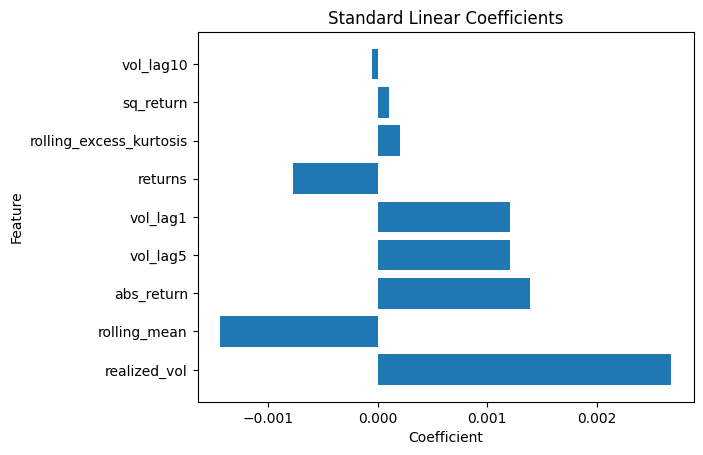

In [20]:
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": linear_model.coef_
})
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Standard Linear Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

We notice realized volatility has the largest magnitude standard coefficient. This is reasonable considering  our previous analysis. Due to the pronounced volatility persistence present in our data current volatility has strong linear correlation with future volatility. 

Rolling_mean is second in magnitude of standard coefficient but with a negative sign.This suggests the model has learned some type of leverage effect: periods of negative average log returns correlate with increased volatility whereas periods of positive average log returns correlate with decreased volatility.

### Feature Selection - Linear Regression

We use two different feature selection methods. We apply a permutation feature analysis where we randomly shuffle the data of each feature one by one and compare the prediction's MAE on the validation set and also use an ablation test in which we retrain the model after dropping each feature and compare MAE on the validation set. 

These two methods give us different information about the how the features are used by the model. The feature ablation test tells us how the model's performance changes if a feature had never been available during training, while the permutation feature analysis tells us how the existing model's performance changes if the information contained in the feature is shuffled, thereby eliminating the information contained in it.

In [21]:
results_lr = find_feature_importance(linear_model, X_validation_scaled,Y_validation)
results_lr_ablation = feature_ablationtest_importance('linear', X_train, Y_train, X_validation, Y_validation)

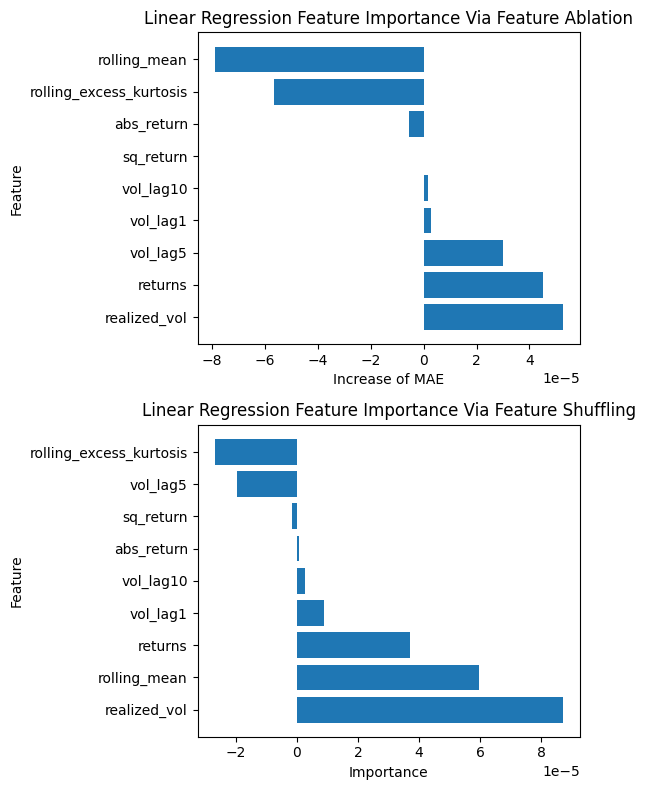

In [22]:
importance_lr = pd.DataFrame(results_lr.items(), columns=["Feature", "Importance"]).sort_values("Importance", ascending=False)
importance_lr_ablation = pd.DataFrame(results_lr_ablation.items(), columns=["Feature", "Importance"]).sort_values("Importance", ascending=False)
fig, (ax1,ax2) = plt.subplots(nrows=2,ncols=1, figsize=(6,8))
ax1.barh(importance_lr_ablation["Feature"], importance_lr_ablation["Importance"])
ax1.set_title("Linear Regression Feature Importance Via Feature Ablation")
ax1.set_ylabel("Feature")
ax1.set_xlabel("Increase of MAE")
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax2.barh(importance_lr["Feature"], importance_lr["Importance"])
ax2.set_title("Linear Regression Feature Importance Via Feature Shuffling")
ax2.set_ylabel("Feature")
ax2.set_xlabel("Importance")
plt.tight_layout()
plt.show()

We first examine the communalites of the feature analyses.

We notice that current realized_volatility ranks highest or second highest in predictive power for both feature selection methods. This is to be expected from our previous analysis. Due to the pronounced volatility persistence present in our data current volatility has strong linear correlation with future volatility. 

Returns also seem to add some incremental information though the ranking differs between the feature selection methods. The feature ablation test shows that removing the feature returns and retraining leads to the largest increase in MAE on the validation set. This suggests that returns contains incremental information not reconstructable by the other features. 

Squared returns, vol_lag10 and rolling_excess_kurtosis all seem to hold limited/negligible incremental predictive power. The predictive information contained in squared_returns is likely already contained in abs_returns: the magnitude of daily shocks. The lack of incremental information in vol_lag10 coincides with our analysis above, since we noticed a clear decay structure in the linear volatility autocorrelation. Rolling_excess_kurtosis also seems to have no linear predictive power for future volatility. We will see later whether it contains nonlinear predictive power.

Now we notice some differences between the rankings of the two plots.

Interestingly we see a massive difference in the ranking of rolling_mean between the feature ablation method vs the shuffling method as well as our visualiztion of the model above via standard coefficeint analysis. Rolling_mean is second in magnitude of standard coefficient but with a negative sign. It also ranks second in importance determined by increase of MAE after shuffling. These two plots together seem to suggest the model has learned some type of leverage effect: periods of negative average log returns correlate with increased volatility whereas periods of positive average log returns correlate with decreased volatility. However, the feature ablation method shows that removing the feature and retraining greatly decreases mean absolute error in the validation test set. This could suggest the leverage effect signal is time period dependent; the training data contains a period of extreme volatility: the early 2020 COVID-19 volatility spike. During this period the leverage effect was likely much stronger than in the calmer validation set period, thus removing the feature and allowing the model to retrain improves performance. 

Since the shuffling test ranks rolling_mean as second highest in importance and combined with the negative coefficient observed by the standard coefficient this signal coencides with a known phenomenon of financial time series i.e the leverage effect we choose to keep the feature rolling_mean despite the results of the ablation test but note that the results of the ablation test indicate the signal is regime dependent. 

The "short" and "medium-term"-memory volatility features vol_lag1 and vol_lag5 both lead to positive increase in MAE in the ablation test, yet shuffling the data in vol_lag5 for the validation set after training appears to improve predictions. This suggests the feature contains incremental information though the currently learned coefficient may be imporfect due to multicolinearity. Thus we keep both features and remove the long-term memory volatility feature vol_lag10.

The shuffling test appears to indicate that absolute returns contain some incremental information, yet the ablation test appears to indicate eliminating absolute returns improves performance while eliminating squared returns has a negligible effect on performance. Since only one feature is eliminated at a time for the ablation test it is still prudent to keep one of the features. Since both features contain very similar information about magnitude of daily shocks the other feature is able to compensate the loss of information of the other in the ablation test. We thus keep the absolute_returns feature and eliminate the squared_returns. The choice between the two is relatively arbitrary, we keep absolute_returns simply because it had better performance in the shuffle test. 

We will remove the features rolling_excess_kurtosis, vol_lag10 and squared_returns and compare performance. 

In [23]:
X_train_reduced = X_train.drop(columns=[ 'vol_lag10', 'sq_return','rolling_excess_kurtosis'])
X_validation_reduced = X_validation.drop(columns=[ 'vol_lag10', 'sq_return', 'rolling_excess_kurtosis'])


linear_model_reducedfeatures, scaler_reduced = train_linear_regression(X_train_reduced, Y_train)
X_train_reduced_scaled = scaler_reduced.transform(X_train_reduced)
X_train_reduced_scaled = pd.DataFrame(X_train_reduced_scaled,columns=X_train_reduced.columns, index=X_train_reduced.index)
pred_train_reduced = model_prediction(linear_model_reducedfeatures, X_train_reduced_scaled)
X_validation_reduced_scaled = scaler_reduced.transform(X_validation_reduced)
X_validation_reduced_scaled = pd.DataFrame(X_validation_reduced_scaled,columns=X_validation_reduced.columns, index=X_validation_reduced.index)
pred_validation_reduced = model_prediction(linear_model_reducedfeatures, X_validation_reduced_scaled)
pred_validation_reduced = pd.Series(pred_validation_reduced, index=Y_validation.index)
pred_validation = model_prediction(linear_model, X_validation_scaled)
pred_validation = pd.Series(pred_validation, index=Y_validation.index)
evaluate_performance("Reduced Linear Model", pred_train_reduced, pred_validation_reduced,"Validation Data", Y_train, Y_validation)

compare_prediction("Comparision Reduced Linear Model vs Full Feature Linear model on Validation Data", pred_validation,"Full Feature Linear Model", pred_validation_reduced,"Reduced Feature Linear Model", Y_validation)


Reduced Linear Model Model Performance on Training Data vs. Validation Data
---------------------------------------------------------------------------
          Data Set       MAE       MSE       R^2
0    Training Data  0.004171  0.000043  0.526789
1  Validation Data  0.002856  0.000013  0.019652

Comparision Reduced Linear Model vs Full Feature Linear model on Validation Data
--------------------------------------------------------------------------------
                          Model       MAE       MSE       R^2  \
0     Full Feature Linear Model  0.002912  0.000014 -0.006037   
1  Reduced Feature Linear Model  0.002856  0.000013  0.019652   

   Strictly Lower Error Frequency (%)  
0                              45.136  
1                              54.864  


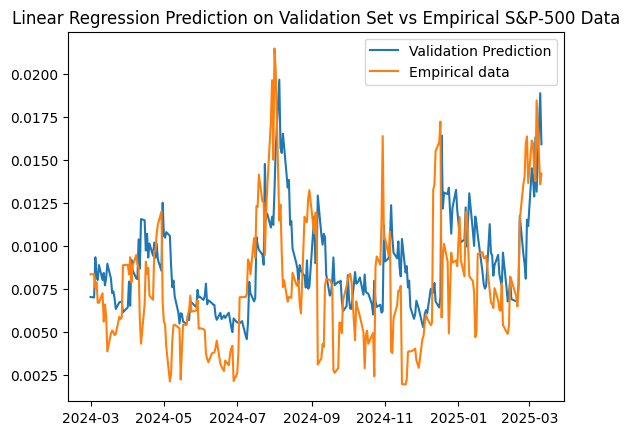

In [24]:
plt.plot(pred_validation, label="Validation Prediction")
plt.plot(Y_validation, label="Empirical data")
plt.legend()
plt.title("Linear Regression Prediction on Validation Set vs Empirical S&P-500 Data")
plt.show()

We notice the model manages to increase predictive power with the reduced set of features.  

Thus, we continue with the more compact set of features and now only refer to the linear model with reduced features as the linear model. 

### Linear Regression vs. Naive Baseline Model and GARCH(1,1)

We plot the predicted volativity of the naive and linear regression model vs. the realized volatility and compare the error metrics of the final linear regression model with the two baseline models. 

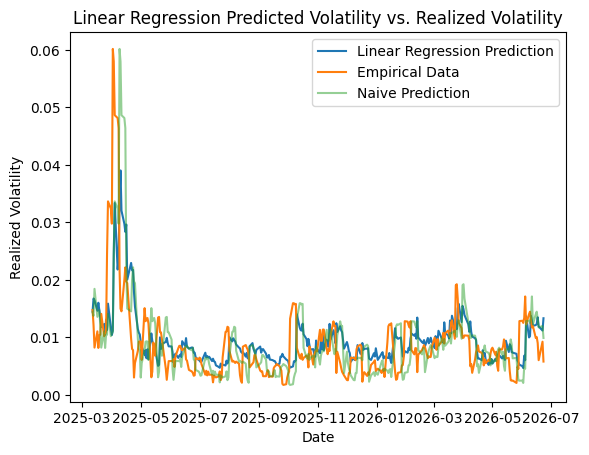

In [25]:
X_test_reduced = X_test.drop(columns=[ 'vol_lag10', 'sq_return', 'rolling_excess_kurtosis'])
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)
X_test_reduced_scaled = pd.DataFrame(X_test_reduced_scaled,columns=X_test_reduced.columns, index=X_test_reduced.index)
pred_test_reduced = model_prediction(linear_model_reducedfeatures, X_test_reduced_scaled)
pred_test_reduced = pd.Series(pred_test_reduced, index=Y_test.index)

plt.plot(pred_test_reduced,label="Linear Regression Prediction")
plt.plot(Y_test, label="Empirical Data")
plt.plot(naive_pred_test,label="Naive Prediction",alpha=0.5)
plt.legend()
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.title("Linear Regression Predicted Volatility vs. Realized Volatility")
plt.show()

In [26]:
common_index = (Y_test.index.intersection(pred_test_reduced.index).intersection(garch_pred.index).intersection(naive_pred_test.index))
y_common = Y_test.loc[common_index]
linear_common = pred_test_reduced.loc[common_index]
garch_common = garch_pred.loc[common_index]
naive_common = naive_pred_test.loc[common_index]
compare_prediction("Test Prediction Results Linear Model vs. Naive Model", linear_common, "Linear Model", naive_common, "Naive Prediction", y_common)
compare_prediction("Test prediction Results Linear Model vs GARCH (1,1)", linear_common, "Linear Model", garch_common, "Garch(1,1) Model", y_common)


Test Prediction Results Linear Model vs. Naive Model
----------------------------------------------------
              Model       MAE       MSE       R^2  \
0      Linear Model  0.004073  0.000041  0.210617   
1  Naive Prediction  0.004725  0.000059 -0.149696   

   Strictly Lower Error Frequency (%)  
0                              56.698  
1                              43.302  

Test prediction Results Linear Model vs GARCH (1,1)
---------------------------------------------------
              Model       MAE       MSE       R^2  \
0      Linear Model  0.004073  0.000041  0.210617   
1  Garch(1,1) Model  0.004494  0.000047  0.084339   

   Strictly Lower Error Frequency (%)  
0                              57.944  
1                              42.056  


Due to the naive prediction simply being a time-shifted version of the target variable, it accumulates large errors during the short high peaks due to the time lag. During stable periods the naive model does relatively well. Despite the linear model not being able to predict the magnitude of the peaks well, its timing improvement results in an overall significant reduction in MAE and especially a reduction in very large magnitude errors. 

The reduced model is able to improve on the naive model by 13.8 percent and GARCH(1,1) by 9.4 percent with respect to MAE, again suggesting the dynamics captured by the linear model go beyond the simple variance dynamics captured by GARCH. We see for instance from the feature selection that, depending on regime, access to the feature rolling_mean allows the model to learn some type of leverage effect. This could explain the linear models outperformance of the GARCH(1,1) model. 



We move on to the Random Forest model to see if we can achieve further improvement upon the two comparison models by relaxing the linearity assumption underlyling linear regression. 

### Random Forest Model
Since the features we trimmed from the linear model could have some non-linear predictive power not captured by the coefficient analysis for the linear model we start with the full feature set. 

To decide the optimal maximum depth and minimum observations per leaf we run the function tune_random_forest which trains a random forest on different depths and min_per_leaf and compares the MAE on the validation set in order to return the best (depth, min_per_leaf) combination based off of validation MAE. 


In [27]:
tune_random_forest(X_train, Y_train, X_validation, Y_validation)

Best params: (5, 30)


The method reveals an optimal maximum depth of 5 and minimum observations per leaf of 30. We set these parameters in our training method and train the model. 

In [28]:
rf_model = train_random_forest(X_train, Y_train)
pred_train_rf = model_prediction(rf_model, X_train)
pred_test_rf = model_prediction(rf_model, X_test)
pred_train_rf = pd.Series(pred_train_rf, index=Y_train.index)
pred_test_rf = pd.Series(pred_test_rf, index=Y_test.index)
common_index_test = common_index.intersection(pred_test_rf.index)
y_test_common = Y_test.loc[common_index_test]
linear_common = pred_test_reduced.loc[common_index_test]
garch_common = garch_pred.loc[common_index_test]
naive_common = naive_pred_test.loc[common_index_test]
rf_test_common = pred_test_rf.loc[common_index_test]
common_index_train = (Y_train.index.intersection(pred_train_rf.index))
y_train_common = Y_train.loc[common_index_train]
rf_train_common = pred_train_rf.loc[common_index_train]
evaluate_performance("Random Forest",rf_train_common, rf_test_common,"Test Data", y_train_common, y_test_common)
compare_prediction("Performance of Random Forest vs Linear Model on Test Data",rf_test_common, "Random Forest Model",linear_common,"Linear Model", y_test_common)
compare_prediction("Performance of Random Forest vs GARCH(1,1) Model on Test Data",rf_test_common, "Random Forest Model",garch_common,"GARCH(1,1) Model", y_test_common)


Random Forest Model Performance on Training Data vs. Test Data
--------------------------------------------------------------
        Data Set       MAE       MSE       R^2
0  Training Data  0.003919  0.000043  0.523377
1      Test Data  0.003747  0.000035  0.327141

Performance of Random Forest vs Linear Model on Test Data
---------------------------------------------------------
                 Model       MAE       MSE       R^2  \
0  Random Forest Model  0.003747  0.000035  0.327141   
1         Linear Model  0.004073  0.000041  0.210617   

   Strictly Lower Error Frequency (%)  
0                              52.336  
1                              47.664  

Performance of Random Forest vs GARCH(1,1) Model on Test Data
-------------------------------------------------------------
                 Model       MAE       MSE       R^2  \
0  Random Forest Model  0.003747  0.000035  0.327141   
1     GARCH(1,1) Model  0.004494  0.000047  0.084339   

   Strictly Lower Error Frequenc

The Random Forest is able to improve the MAE by approximately 8% suggesting that nonlinear signal contributes to improved volatility forecasting. Considering the fact that Random Forest models predict using observation averaging and cannot extrapoloate the same way that a linear regression model can, this result is counterintuitive, even considering the fact that the Random Forest is not bound by linearity.

To understand the model's improvement over the linear model we plot the linear model's prediction alongside the random forest prediction vs. the empirical data.

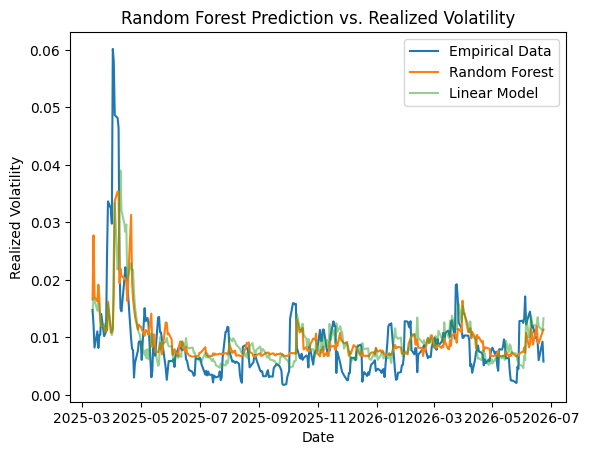

In [29]:
plt.plot(Y_test, label="Empirical Data")
plt.plot(pred_test_rf, label="Random Forest")
plt.plot(pred_test_reduced, label="Linear Model", alpha=0.5)
plt.title("Random Forest Prediction vs. Realized Volatility")
plt.ylabel("Realized Volatility")
plt.xlabel("Date")
plt.legend()
plt.show()

Comparing the two model's predictions, a clear story emerges about the origin of the Random Forest's improvement over the linear model. 

We notice immediately, that the Random Forest's trajectory fluctuates much less over short time frames than the linear model. 

Contrary to our intuition about the limitations of the Random Forest's averaging methodology, the Random Forest achieves lower MAE precisely due to its averaging mechanism. The observation-averaging mechanism tends to cause smoothed prediction paths as each prediction of a single tree is an average of observations which are themselves averaged over many trees, causing extreme spikes to be dampened. For a noisy target like the 5-day lookahead volatility, this is beneficial as the short-term fluctuations are very noisy and cannot be predicted reliably. 

The linear model on the other hand fluctuates considerably in response to short term fluctuations in its features, sometimes overshooting and sometimes undershooting the empirical fluctuations, resulting overall in higher MAE. 

While both models capture the slow-moving volatility dynamics, the instability of the linear model's predictions results in overall poorer performance. This suggests that for this problem, prediction stability is an important factor to consider alongside feature informativeness and flexibility. Thus, the Random Forest's methodological tendency toward smoothing is better suited for the noise characteristics of 5-day realized volatility. 

### Feature Selection - Random Forest


In [30]:
results_rf = find_feature_importance(rf_model, X_validation, Y_validation)
results_rf_ablation = feature_ablationtest_importance('rf', X_train, Y_train, X_validation, Y_validation)


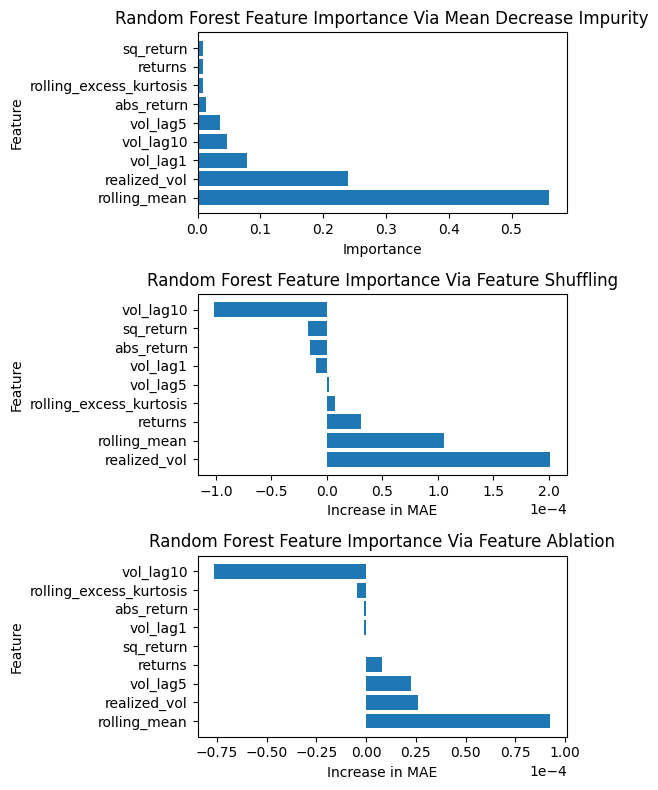

In [31]:
importance_rf_shuffling = pd.DataFrame(results_rf.items(), columns=["Feature", "Importance"]).sort_values("Importance", ascending=False)
importance_rf_ablation = pd.DataFrame(results_rf_ablation.items(), columns=["Feature", "Importance"]).sort_values("Importance", ascending=False)
importance_rf_meandecreaseimpurity = pd.DataFrame({"Feature": X_train.columns,"Importance": rf_model.feature_importances_}).sort_values("Importance", ascending=False, key=abs)
fig, (ax1,ax2, ax3) = plt.subplots(nrows=3,ncols=1, figsize=(6,8))
ax1.barh(importance_rf_meandecreaseimpurity["Feature"], importance_rf_meandecreaseimpurity["Importance"])
ax1.set_title("Random Forest Feature Importance Via Mean Decrease Impurity")
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")
ax2.barh(importance_rf_shuffling["Feature"], importance_rf_shuffling["Importance"])
ax2.set_title("Random Forest Feature Importance Via Feature Shuffling")
ax2.set_ylabel("Feature")
ax2.set_xlabel("Increase in MAE")
ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax3.barh(importance_rf_ablation["Feature"], importance_rf_ablation["Importance"])
ax3.set_title("Random Forest Feature Importance Via Feature Ablation")
ax3.set_ylabel("Feature")
ax3.set_xlabel("Increase in MAE")
ax3.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.tight_layout()
plt.show()


We rely only on the shuffling test and ablation test for decisions about feature selection and use the Mean Decrease Impurity test more as a visualization of the model's currently learned decision separators.

We compare the feature rankings between the shuffling and ablation test. 

Rolling_mean and realized volatility clearly rank highest in importance for the Random Forest model as they are the top features across the two selection methods. Returns also seem to add some incremental information according to the ablation test and shuffling test, thus we keep these features for the final feature set.

Vol_lag10, sq_returns, abs_returns, and vol_lag1 all have negative/negligibly positive importance according to both ablation and shuffling test, thus we remove these features from the final feature set. 

We notice rolling_excess_kurtosis has slight positive importance according to the shuffling test, but negative in the ablation test, thus we remove it from the feature set. 

Vol_lag5 has slight positive importance according to the shuffling test as well as significant positive importance in the ablation test, thus we keep this feature for the final feature set.

We thus remove the features rolling_excess_kurtosis, sq_returns, abs_returns, vol_lag1, and vol_lag10 and keep rolling_mean, realized_volatility, returns, and vol_lag5.


In [32]:
X_train_reduced_rf = X_train.drop(
    columns=['rolling_excess_kurtosis', 'sq_return', 'abs_return', 'vol_lag1', 'vol_lag10']
    )
X_validation_reduced_rf = X_validation.drop(
    columns=['rolling_excess_kurtosis', 'sq_return', 'abs_return', 'vol_lag1', 'vol_lag10']
    )
X_test_reduced_rf = X_test.drop(
    columns=['rolling_excess_kurtosis', 'sq_return', 'abs_return', 'vol_lag1', 'vol_lag10']
    )

rf_model_reduced = train_random_forest(X_train_reduced_rf, Y_train)
pred_train_rf_reduced = model_prediction(rf_model_reduced, X_train_reduced_rf)
pred_validation_rf = model_prediction(rf_model,X_validation)
pred_validation_rf_reduced = model_prediction(rf_model_reduced, X_validation_reduced_rf)
pred_validation_rf_reduced = pd.Series(pred_validation_rf_reduced, index=Y_validation.index)
pred_train_rf_reduced = pd.Series(pred_train_rf_reduced, index=Y_train.index)
evaluate_performance("Reduced Random Forest",pred_train_rf_reduced,pred_validation_rf_reduced, "Validation Data" ,Y_train, Y_validation)
compare_prediction("Validation Data Performance Comparision Reduced Randon Forest vs Full Random Forest",pred_validation_rf, "Random Forest Test Full Features", pred_validation_rf_reduced, "Random Forest Reduced", Y_validation)



Reduced Random Forest Model Performance on Training Data vs. Validation Data
----------------------------------------------------------------------------
          Data Set       MAE       MSE       R^2
0    Training Data  0.004045  0.000045  0.502372
1  Validation Data  0.002833  0.000013  0.083826

Validation Data Performance Comparision Reduced Randon Forest vs Full Random Forest
-----------------------------------------------------------------------------------
                              Model       MAE       MSE       R^2  \
0  Random Forest Test Full Features  0.002913  0.000014  0.011413   
1             Random Forest Reduced  0.002833  0.000013  0.083826   

   Strictly Lower Error Frequency (%)  
0                              48.638  
1                              51.362  


The reduced model appears to have even more predictive power than the full feature model. This suggests the removed features contained little incremental information for forecasting future volatility and predictive power is concentrated in the remaining fetuares.

Both the Random Forest model and linear model detected the feature realized_volatility as the most impactful features, suggesting strong volatility persistence.



### Final Analysis Random Forest vs. Linear Model
Now that we have the final, reduced feature set for the Random Forest model, we compare test set performance between the linear model and random forest.

In [33]:
pred_test_rf_reduced = model_prediction(rf_model_reduced, X_test_reduced_rf)
pred_test_rf_reduced = pd.Series(pred_test_rf_reduced, index=Y_test.index)

common_index_test = common_index.intersection(pred_test_rf_reduced.index)
y_test_common = Y_test.loc[common_index_test]
linear_common = pred_test_reduced.loc[common_index_test]
garch_common = garch_pred.loc[common_index_test]
naive_common = naive_pred_test.loc[common_index_test]
rf_test_common = pred_test_rf_reduced.loc[common_index_test]

compare_prediction("Performance of Random Forest vs Linear Model on Test Data",rf_test_common, "Random Forest Model",linear_common,"Linear Model", y_test_common)
compare_prediction("Performance of Random Forest vs GARCH(1,1) Model on Test Data",rf_test_common, "Random Forest Model",garch_common,"GARCH(1,1) Model", y_test_common)


Performance of Random Forest vs Linear Model on Test Data
---------------------------------------------------------
                 Model       MAE       MSE       R^2  \
0  Random Forest Model  0.003805  0.000036  0.293867   
1         Linear Model  0.004073  0.000041  0.210617   

   Strictly Lower Error Frequency (%)  
0                              54.206  
1                              45.794  

Performance of Random Forest vs GARCH(1,1) Model on Test Data
-------------------------------------------------------------
                 Model       MAE       MSE       R^2  \
0  Random Forest Model  0.003805  0.000036  0.293867   
1     GARCH(1,1) Model  0.004494  0.000047  0.084339   

   Strictly Lower Error Frequency (%)  
0                              65.109  
1                              34.891  


We notice a small performance decrease on the reduced model on the test set vs. the full set. (MAE + 1.5%, $R^2$ - 0.03). Feature selection was performed on the validation set only, thus we attribute this difference as expected variation between validation and test regimes rather than overfitting to validation set, since the gap is small and consistent with the magnitude of noise seen elsewhere in this analysis. 

Comparing the final results, Random Forest outperforms the linear model in MAE by approximately 6.5% and increasing $R^2$ by 0.08. 

We expected the Random Forest's averaging methodology and resulting inability to extrapolate to be a limitation for the model compared to the linear regression model, but the resulting increase in prediction stability proved a strength for predicting such a noisy target variable. The tendency of a forest's averaging methodology to smooth out extremes results in overall increased prediction stability leading to a lower MAE compared to the linear regression model, which is more sensitive to short term fluctuations in its features. 


We have seen from the random forest's outperformance of the linear model, that it is important to consider prediction stability alongside feature informativeness. We will now test whether the increased flexibility of a neural network, which is neither bounded by linearity nor bounded to observation averaging leads to increased performance or whether this flexibility could even be detrimental for such a noisy target. 

### Neural Network Model
We choose a basic feed-forward network as our comparison model with ReLU activation in the input and intermediate layers and linear activation in the output layer. 

In [34]:
# Since the Keras methods break off the last 20 percent of the training data to use as the validation set, 
# We use the full training and validation set as the training set for the neural model
X_trainandvalidation_nn = X_trainandvalidation.to_numpy(dtype=np.float32)
X_test_nn = X_test.loc[common_index_test].to_numpy(dtype=np.float32)
y_trainandvalidation_nn = Y_trainandvalidation.to_numpy(dtype=np.float32)
X_train_nn = X_train.to_numpy(dtype=np.float32)
y_train_nn = Y_train.to_numpy(dtype=np.float32)

We run the test choose_architecture. This test runs through a list of 21 architectures of varying complexity and determines the validation set MAE of the architecture across 20 different seeds accounting for weight-initiation-differences between different seeds. Then, the architecture with the lowest MAE is selected as the "best architecture" for comparison. The statistical properties of the seed runs of the best architecture is then used to select all the architectures that have statistically-equivalent MAE using a Welch two-sample t-test (which does not assume equal variances). Architectures with p>=0.05 were considered statistically-indistinguishable from the best performer architecture. Among the architectures considered statistically-indistinguishable, the architecture  with the fewest parameters was selected, appying a parsimony principle given the small amount of data. 

The results are stored in the results folder in architecture_results.csv. During the test the partial summary as well as raw results of each architecture are stored in the files architecture_results_partial.csv and raw_results_partial.pkl respectively so that in the event of a crash the test can continue where it left off instead of recalculating the mae per seed per architecture. If it is necessary to rerun this test due to change in model or change in data, the partial results need to be manually deleted. This is done because running this test takes several hours if all MAE per seed per architecture have to be calculated, so by default we do not want the test to be rerun on every Kernel restart.

In [35]:
results, selected = choose_architecture(X_trainandvalidation, Y_trainandvalidation, X_test, Y_test)

Resuming — 20 architectures already completed.
           architecture      mean       std  n_params  p_value_vs_best  \
0       [512, 256, 128]  0.002662  0.000053    169492     1.000000e+00   
1            [512, 256]  0.002666  0.000047    136724     8.225297e-01   
2             [180, 90]  0.002681  0.000048     18200     2.455692e-01   
3            [256, 128]  0.002687  0.000048     35604     1.232618e-01   
4   [512, 256, 128, 64]  0.002712  0.000042    177684     2.213357e-03   
5        [256, 128, 64]  0.002719  0.000047     43796     1.046137e-03   
6             [128, 64]  0.002744  0.000069      9620     1.602844e-04   
7              [64, 32]  0.002775  0.000086      2772     2.117531e-05   
8         [180, 90, 45]  0.002826  0.000083     22250     1.749020e-08   
9    [256, 128, 64, 32]  0.002829  0.000087     45844     2.562386e-08   
10        [128, 64, 32]  0.002844  0.000085     11668     3.247339e-09   
11    [180, 90, 45, 20]  0.002887  0.000088     23145     4.84251

Thus our test determines the architecture determines [180,90] to be the optimal architecture according to the criteria we determined above. We set these parameters in the model and determine baseline performance. 

In [36]:
neural_model, history = train_neural_network(X_trainandvalidation_nn, y_trainandvalidation_nn)
print(history.history["loss"][-1])
print(history.history["val_loss"][-1])
y_pred_neural_train = model_prediction(neural_model, X_train_nn)
y_pred_neural_test = model_prediction(neural_model, X_test_nn)
y_pred_neural_train = pd.Series(y_pred_neural_train.flatten(), index=Y_train.index)
y_pred_neural_test = pd.Series(y_pred_neural_test.flatten(), index=Y_test.loc[common_index_test].index)
common_index_train = (Y_train.index.intersection(pred_train_rf_reduced.index).intersection(y_pred_neural_train))
y_train_common = Y_train.loc[common_index_train]
rf_train_common = pred_train_rf.loc[common_index_train]
evaluate_performance("Neural Network", y_pred_neural_train, y_pred_neural_test, "Test Data",Y_train, y_test_common)
compare_prediction("Linear Model vs Neural Model Prediction", y_pred_neural_test,"Neural Model",rf_test_common,"Random Forest Model", y_test_common)


Epoch 1/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1434 - mse: 0.0663 - val_loss: 0.0380 - val_mse: 0.0025 - learning_rate: 1.0000e-04
Epoch 2/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1041 - mse: 0.0331 - val_loss: 0.0305 - val_mse: 0.0017 - learning_rate: 1.0000e-04
Epoch 3/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0951 - mse: 0.0319 - val_loss: 0.0259 - val_mse: 0.0013 - learning_rate: 1.0000e-04
Epoch 4/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0927 - mse: 0.0295 - val_loss: 0.0246 - val_mse: 0.0012 - learning_rate: 1.0000e-04
Epoch 5/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0907 - mse: 0.0286 - val_loss: 0.0224 - val_mse: 0.0011 - learning_rate: 1.0000e-04
Epoch 6/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0837 - mse: 0.0231 - val_loss: 0.0222 - val_mse: 9.4341e-04 - learning_rate: 1.0000e-04
Epoch 7/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0772 - mse: 0.0207 - val_loss: 0.0209 - val_mse: 8.9135e-

Since the MAE of a single seed-run is susceptible to weight-initiialization differences, we run the test validate_seed_robustness to use the 20-seed averaged MAE and $R^2$ as our comparison MAE and $R^2.$

Since the test takes around 15 minutes to run we comment it out by default for the full build and report the results for our run. 

In [37]:
results = validate_seed_robustness(X_trainandvalidation, Y_trainandvalidation, X_test.loc[common_index_test], Y_test.loc[common_index_test])

Epoch 1/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1060 - mse: 0.0353 - val_loss: 0.0442 - val_mse: 0.0031 - learning_rate: 1.0000e-04
Epoch 2/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0900 - mse: 0.0332 - val_loss: 0.0303 - val_mse: 0.0017 - learning_rate: 1.0000e-04
Epoch 3/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0804 - mse: 0.0225 - val_loss: 0.0272 - val_mse: 0.0014 - learning_rate: 1.0000e-04
Epoch 4/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0779 - mse: 0.0166 - val_loss: 0.0235 - val_mse: 0.0011 - learning_rate: 1.0000e-04
Epoch 5/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0763 - mse: 0.0226 - val_loss: 0.0218 - val_mse: 9.2755e-04 - learning_rate: 1.0000e-04
Epoch 6/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0686 - mse: 0.0149 - val_loss: 0.0195 - val_mse: 8.0204e-04 - learning_rate: 1.0000e-04
Epoch 7/1000
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0668 - mse: 0.0183 - val_loss: 0.0181 - val_mse: 7.01

With a mean MAE of $0.003652 \pm 0.000087$ and mean $R^2$ of $0.2023 \pm 0.0364$, the neural model outperforms the Random Forest model by approximately 4% leading to a total improvement over the GARCH(1,1) model of 18.7% in MAE.  The model perfoms worse than the Random forest model with respect to $R^2$, (-0.09), suggesting it commits more large errors while still managing to reduce overall error. 

The improvement over the Random forest in MAE is modest despite the increase in flexibility lended by the neural model. To visualize the difference in performance we plot the two models vs. the empirical test data. 

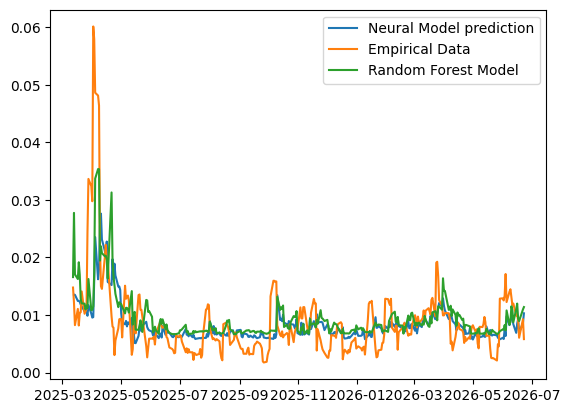

In [44]:
plt.plot(y_pred_neural_test, label="Neural Model prediction")
plt.plot(Y_test, label="Empirical Data")
plt.plot(pred_test_rf, label="Random Forest Model")
plt.legend()
plt.show()

Comparing the two predictions, it appears the neural model follows a similar "flattened" prediction strategy to the random forest: predictions remain stable close to a predicted mean during the stable periods with only small noisy fluctuations along a mean. The neural model appears to better predict the mean during these periods which likely contributes to overall reduction in MAE.

During the early 2025 spike we see the neural model reacts much less to the short April spike than the Random forest model. This could be the cause for the difference in $R^2$ performance. Due to the quadratic penalty, $R^2$ is more sensitive to spike-period errors. We test this theory more directly by examing spike and non-spike MAE of the random forest and neural model respectively. 

In [45]:
print(type(common_index_test))
print(common_index_test.dtype)
print(common_index_test[:5])
common_index_test = pd.to_datetime(common_index_test)
spike_mask = (common_index_test >= '2025-03-01') & (common_index_test <= '2025-05-01')
for name, preds in [('NN', y_pred_neural_test), ('RF', rf_test_common)]: 
    mae_spike = np.mean(np.abs(preds[spike_mask] - y_test_common[spike_mask]))
    mae_rest = np.mean(np.abs(preds[~spike_mask] - y_test_common[~spike_mask]))
    print(f"{name}: spike MAE+{mae_spike:.5f}, non-spike MAE+{mae_rest:.5f}")

<class 'pandas.DatetimeIndex'>
datetime64[s]
DatetimeIndex(['2025-03-13', '2025-03-14', '2025-03-17', '2025-03-18',
               '2025-03-19'],
              dtype='datetime64[s]', freq=None)
NN: spike MAE+0.01092, non-spike MAE+0.00265
RF: spike MAE+0.01024, non-spike MAE+0.00302


This test confirms our theory. We see the neural model outperforms the Random Forest model in MAE during the stabler, non-spike period by 12.2% (0.00265 vs 0.00302), but the Random Forest outperforms the neural model in the spike period by 6,2 % (0.001092 vs 0.001024), causing poorer performance in $R^2$ due to the error terms being weighted quadratically vs linearly in MAE. 

We move on to the feature analysis and selection of the neural model, using the ablation test and the permutation shuffle test. 

### Neural Model Feature Selection and Analysis

In [50]:
feature_results = find_feature_importance(neural_model,X_validation,Y_validation)
importance_nn = pd.DataFrame(feature_results.items(), columns=["Feature", "Importance"]).sort_values("Importance", ascending=False)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━

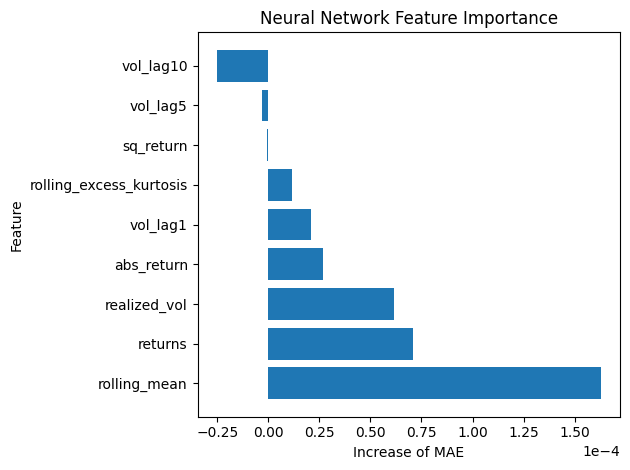

In [52]:
plt.barh(importance_nn["Feature"], importance_nn["Importance"])
plt.title("Neural Network Feature Importance")
plt.ylabel("Feature")
plt.xlabel("Increase of MAE")
plt.tight_layout()
ax = plt.gca()
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.show()

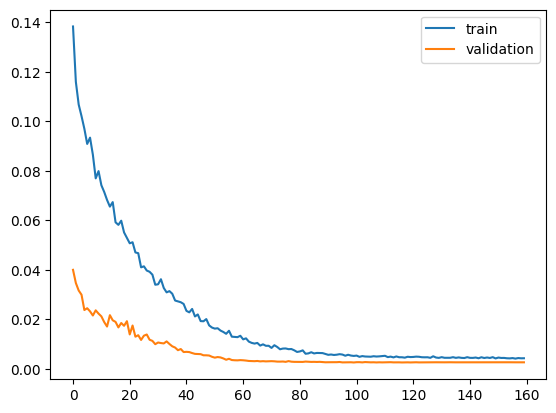

In [38]:
plt.plot(history_optimized.history["loss"], label="train")
plt.plot(history_optimized.history["val_loss"],label="validation")
plt.legend()
plt.show()

In [32]:
X_train_nn_minimal_reduced = X_train_reduced_rf.to_numpy(dtype=np.float32)
X_test_nn_minimal_reduced = X_test_reduced_rf.to_numpy(dtype=np.float32)
neural_model_minimal_reduced, history_minimal_reduced = train_neural_network(X_train_nn_minimal_reduced, y_train_nn)
print(history_minimal_reduced.history["loss"][-1])
print(history_minimal_reduced.history["val_loss"][-1])
y_pred_neural_train_minimal_reduced = model_prediction(neural_model_minimal_reduced, X_train_nn_minimal_reduced)
y_pred_neural_test_minimal_reduced = model_prediction(neural_model_minimal_reduced, X_test_nn_minimal_reduced)
y_pred_neural_train_minimal_reduced = pd.Series(y_pred_neural_train_minimal_reduced.flatten(), index=Y_train.index)
y_pred_neural_test_minimal_reduced = pd.Series(y_pred_neural_test_minimal_reduced.flatten(), index=Y_test.index)
evaluate_performance("Minimal Reduced Neural Network", y_pred_neural_train_minimal_reduced, y_pred_neural_test_minimal_reduced, Y_train, Y_test)
compare_prediction("Minimal Feature Neural Network vs Full Feature Neural Model Prediction", y_pred_neural_test_minimal_reduced,"Minimal Feature Neural Model", y_pred_neural_test,"Full Feature Neural Model", Y_test)
result_minimal = validate_seed_robustness(X_train_reduced_rf, Y_train, X_test_reduced_rf, Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0456 - mse: 0.0091 - val_loss: 0.0118 - val_mse: 1.9197e-04
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0254 - mse: 0.0041 - val_loss: 0.0027 - val_mse: 1.0485e-05
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0148 - mse: 0.0014 - val_loss: 0.0019 - val_mse: 6.1382e-06
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0106 - mse: 0.0011 - val_loss: 0.0020 - val_mse: 6.9912e-06
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0078 - mse: 6.5375e-04 - val_loss: 0.0011 - val_mse: 1.9713e-06
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0052 - mse: 2.1021e-04 - val_loss: 0.0013 - val_mse: 2.4125e-06
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0047 - mse: 2.5878e-04 - val_loss: 0.0016 - val_mse: 3.8992e-06
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035 - mse: 1.0017e-04 - val_loss: 0.0018 - val_mse: 4.5116e-06


In [42]:
X_train_reduced_fivefeatures= X_train.drop(columns=['returns','vol_lag5', 'vol_lag10', 'rolling_excess_kurtosis'])
X_train_nn_reduced = X_train_reduced_fivefeatures.to_numpy(dtype=np.float32)
X_test_reduced_fivefeatures = X_test.drop(columns=['returns','rolling_excess_kurtosis','vol_lag5', 'vol_lag10'])
X_test_nn_reduced = X_test_reduced_fivefeatures.to_numpy(dtype=np.float32)
neural_model_reduced, history_reduced = train_neural_network(X_train_nn_reduced, y_train_nn)
print(history_reduced.history["loss"][-1])
print(history_reduced.history["val_loss"][-1])
y_pred_neural_train_reduced = model_prediction(neural_model_reduced, X_train_nn_reduced)
y_pred_neural_test_reduced = model_prediction(neural_model_reduced, X_test_nn_reduced)
y_pred_neural_train_reduced = pd.Series(y_pred_neural_train_reduced.flatten(), index=Y_train.index)
y_pred_neural_test_reduced = pd.Series(y_pred_neural_test_reduced.flatten(), index=Y_test.index)
evaluate_performance("Reduced Neural Network", y_pred_neural_train_reduced, y_pred_neural_test_reduced, Y_train, Y_test)
compare_prediction("Reduced Neural Model vs Full Feauture Neural Model Prediction", y_pred_neural_test_reduced,"Reduced Feature Neural Model", y_pred_neural_test,"Full Feature Neural Model", Y_test)
#validate_seed_robustness(X_train_reduced_fivefeatures, Y_train, X_test_reduced_fivefeatures, Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0940 - mse: 0.0446 - val_loss: 0.0184 - val_mse: 5.6742e-04 - learning_rate: 1.0000e-04
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0737 - mse: 0.0147 - val_loss: 0.0174 - val_mse: 4.6400e-04 - learning_rate: 1.0000e-04
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0702 - mse: 0.0155 - val_loss: 0.0117 - val_mse: 2.4702e-04 - learning_rate: 1.0000e-04
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0693 - mse: 0.0231 - val_loss: 0.0124 - val_mse: 2.7875e-04 - learning_rate: 1.0000e-04
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0685 - mse: 0.0239 - val_loss: 0.0103 - val_mse: 1.9718e-04 - learning_rate: 1.0000e-04
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0606 - mse: 0.0148 - val_loss: 0.0087 - val_mse: 1.4184e-04 - learning_rate: 1.0000e-04
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0566 - mse: 0.0102 - val_loss: 

In [35]:
X_train_nn_reduced = X_train_reduced_rf.to_numpy(dtype=np.float32)
X_test_nn_reduced = X_test_reduced_rf.to_numpy(dtype=np.float32)
neural_model_reduced, history_reduced = train_reduced_neural_network(X_train_nn_reduced, y_train_nn, [256, 128])
print(history_reduced.history["loss"][-1])
print(history_reduced.history["val_loss"][-1])
y_pred_neural_train_reduced = model_prediction(neural_model_reduced, X_train_nn_reduced)
y_pred_neural_test_reduced = model_prediction(neural_model_reduced, X_test_nn_reduced)
y_pred_neural_train_reduced = pd.Series(y_pred_neural_train_reduced.flatten(), index=Y_train.index)
y_pred_neural_test_reduced = pd.Series(y_pred_neural_test_reduced.flatten(), index=Y_test.index)
evaluate_performance("Neural Network", y_pred_neural_train_reduced, y_pred_neural_test_reduced, Y_train, Y_test)
compare_prediction("Linear Model vs Neural Model Prediction", y_pred_neural_test_reduced,"Neural Model", pred_test_reduced,"Linear Model", Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0399 - mse: 0.0093 - val_loss: 0.0055 - val_mse: 3.5621e-05
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0192 - mse: 0.0023 - val_loss: 0.0059 - val_mse: 6.0727e-05
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0117 - mse: 0.0012 - val_loss: 0.0013 - val_mse: 2.6001e-06
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0079 - mse: 6.1076e-04 - val_loss: 0.0011 - val_mse: 1.9655e-06
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0074 - mse: 8.7772e-04 - val_loss: 0.0011 - val_mse: 1.8464e-06
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0047 - mse: 2.1685e-04 - val_loss: 0.0011 - val_mse: 1.7733e-06
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0036 - mse: 1.4025e-04 - val_loss: 0.0011 - val_mse: 1.9513e-06
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0033 - mse: 9.4311e-05 - val_loss: 0.0011 - val_mse: 1.8325e